# Stochastic Interest Rate Modelling: Cox-Ingersoll-Ross (CIR) Model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, differential_evolution
from scipy.special import gamma
from scipy.stats import ncx2
np.random.seed(42)

### Part A: Data Engineering and Preprocessing

for this step,we are going to use interpolation for missing values and we gonna normalize outliers.

In [2]:
MATURITIES = ['3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']
MATURITY_YEARS = [0.25, 0.5, 0.75, 1, 2, 5, 10, 20, 30] #in years

MATURITY_YEAR_MAP = {
    '3M': 0.25,
    '6M': 0.5,
    '9M': 0.75,
    '1Y': 1,
    '2Y': 2,
    '5Y': 5,
    '10Y': 10,
    '20Y': 20,
    '30Y': 30
}



In [3]:
def preprocess_data(filepath):
    """
    function to load and clean data like,missing values,outliers(using IQR method),etc.
    """
    df = pd.read_csv(filepath)

    # we are assuming that the first column is date..
    if 'date' in df.columns[0].lower():
        df[df.columns[0]]=pd.to_datetime(df[df.columns[0]])
        df=df.set_index(df.columns[0])
    else:
        df.index=range(len(df))

    # consider only the maturities that are there in the data
    df.columns=MATURITIES[:len(df.columns)]

    # Convert to numeric,coercing errors to NaN
    for col in df.columns:
        df[col]=pd.to_numeric(df[col], errors='coerce')

    print(f"Original data shape:{df.shape},missing values before cleaning:\n{df.isnull().sum()}")

    # interpolation for missing values
    df=df.interpolate(method='linear',limit_direction='both')
    df = df.bfill().ffill()

    # Remove outliers using IQR method
    for col in df.columns:
        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)
        IQR=Q3-Q1
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        for i in range(len(df)):
            val = df[col].iloc[i]
            if val < lower_bound:
                df.at[df.index[i], col] = lower_bound
            elif val > upper_bound:
                df.at[df.index[i], col] = upper_bound

    print(f"\nCleaned data shape: {df.shape},missing values after cleaning:\n{df.isnull().sum()}")
    return df
    

In [4]:
# Load train and test data
train_data=preprocess_data('train_data.csv')
test_data=preprocess_data('test_data.csv')

# Determine available maturities
AVAILABLE_MATURITIES = []
for m in MATURITIES:
    if m in train_data.columns and m in test_data.columns:
        AVAILABLE_MATURITIES.append(m)

AVAILABLE_MATURITY_YEARS = []
for m in AVAILABLE_MATURITIES:
    AVAILABLE_MATURITY_YEARS.append(MATURITY_YEAR_MAP[m])



Original data shape:(1976, 9),missing values before cleaning:
3M     0
6M     0
9M     0
1Y     0
2Y     0
5Y     0
10Y    0
20Y    0
30Y    0
dtype: int64

Cleaned data shape: (1976, 9),missing values after cleaning:
3M     0
6M     0
9M     0
1Y     0
2Y     0
5Y     0
10Y    0
20Y    0
30Y    0
dtype: int64
Original data shape:(495, 5),missing values before cleaning:
3M    0
6M    0
9M    0
1Y    0
2Y    0
dtype: int64

Cleaned data shape: (495, 5),missing values after cleaning:
3M    0
6M    0
9M    0
1Y    0
2Y    0
dtype: int64


In [5]:
print("\n summary of training data:")
print(train_data.describe())


 summary of training data:
                3M           6M           9M           1Y           2Y  \
count  1976.000000  1976.000000  1976.000000  1976.000000  1976.000000   
mean      0.016699     0.017885     0.018529     0.019174     0.018063   
std       0.016642     0.016760     0.016650     0.016587     0.013661   
min       0.000486     0.000878     0.001054     0.001227     0.001417   
25%       0.004621     0.005190     0.005449     0.005729     0.005897   
50%       0.011912     0.013815     0.015304     0.016335     0.015471   
75%       0.017112     0.019378     0.021077     0.022743     0.025553   
max       0.051962     0.053195     0.054040     0.054941     0.048496   

                5Y          10Y          20Y          30Y  
count  1976.000000  1976.000000  1976.000000  1976.000000  
mean      0.018109     0.020226     0.022823     0.022619  
std       0.010396     0.008805     0.007136     0.006601  
min       0.002786     0.004451     0.008394     0.006921  
25%  

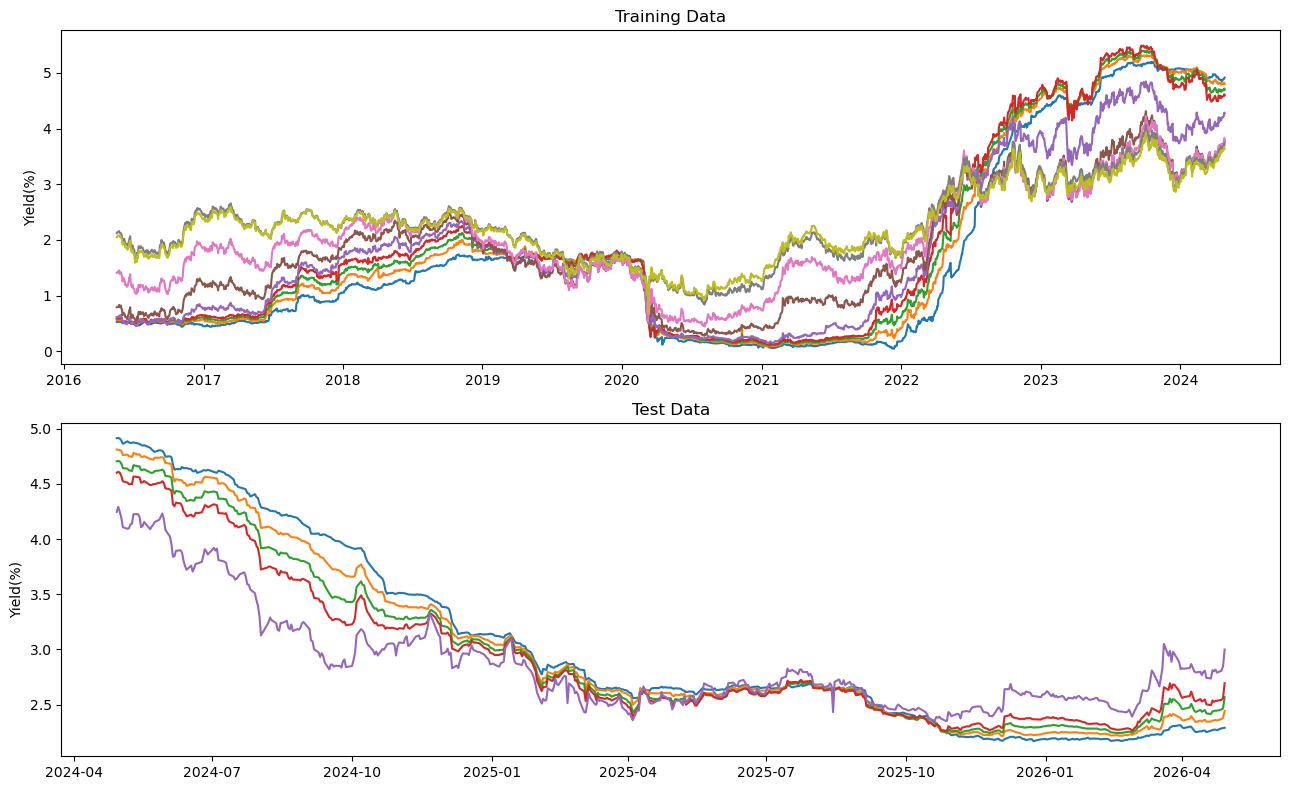

In [6]:
fig,ax=plt.subplots(2,1,figsize=(13,8))

# plot the training data
for mat in MATURITIES:
    ax[0].plot(train_data.index,train_data[mat]*100,label=mat)
ax[0].set_title('Training Data')
ax[0].set_ylabel('Yield(%)')

#plot test data 
for mat in AVAILABLE_MATURITIES:
    ax[1].plot(test_data.index,test_data[mat]*100,label=mat)
ax[1].set_title('Test Data')
ax[1].set_ylabel('Yield(%)')
plt.tight_layout()
plt.show()

## Part B: Base CIR Model Implementation & Calibration

### The CIR Model Mathematics

The CIR model describes short-rate evolution via:
$$dr_t = \kappa(\theta - r_t)dt + \sigma\sqrt{r_t}dW_t$$

Where:
- $\kappa$ = speed of mean reversion
- $\theta$ = long-run mean level  
- $\sigma$ = volatility coefficient
- $W_t$ = standard Brownian motion

This equation has two components:

Drift term ( $\kappa$($\theta$ - r_t) ): pulls the rate towards a long-term mean (mean reversion)
Diffusion term ( $\sigma$ $\sqrt{r_t}$ dW_t ): introduces randomness

The **Feller condition** $2\kappa\theta \geq \sigma^2$ ensures rates remain non-negative.

Zero-coupon bond prices are given by:
$$P(t,T) = A(t,T)e^{-B(t,T)r_t}$$

Where $A(t,T)$ and $B(t,T)$ are deterministic functions of maturity $\tau = T-t$.

The yield curve is derived from bond prices:
$$y(t,\tau) = -\frac{\ln P(t,T)}{\tau} = \frac{B(t,T)r_t - \ln A(t,T)}{\tau}$$



## Derivation of ( A(t,T) ) and ( B(t,T) ) in the CIR Model

### CIR 


### Bond Pricing Formula

The zero-coupon bond price is:

$$
P(t,T) = \mathbb{E}\left[e^{-\int_t^T r_s ds} \mid r_t \right]
$$

---

### Exponential-Affine Form

Assume:

$$
P(t,T) = A(\tau), e^{-B(\tau), r_t}, \quad \tau = T - t
$$

---

### Bond Pricing PDE

$$
\frac{\partial P}{\partial t}

* \kappa(\theta - r)\frac{\partial P}{\partial r}
* \frac{1}{2}\sigma^2 r \frac{\partial^2 P}{\partial r^2}

- rP = 0
  $$

---

### Derivatives

$$
\frac{\partial P}{\partial r} = -B A e^{-Br}
$$

$$
\frac{\partial^2 P}{\partial r^2} = B^2 A e^{-Br}
$$

$$
\frac{\partial P}{\partial t}
= -A' e^{-Br} + A B' r e^{-Br}
$$

---

### Substitute into PDE

$$

* \frac{A'}{A} + B' r
* \kappa(\theta - r) B

- \frac{1}{2}\sigma^2 r B^2

* r = 0
  $$

---

### Equating Terms

#### Coefficient of ( r ):

$$
B' = 1 - \kappa B - \frac{1}{2}\sigma^2 B^2
$$

#### Constant term:

$$
\frac{A'}{A} = \kappa \theta B
$$

---

### Solution for ( B(\tau) )

Define:

$$
\gamma = \sqrt{\kappa^2 + 2\sigma^2}
$$

$$
B(\tau) =
\frac{2(e^{\gamma \tau} - 1)}
{(\gamma + \kappa)(e^{\gamma \tau} - 1) + 2\gamma}
$$

---

### Solution for ( A(\tau) )

$$
A(\tau) =
\left[
\frac{2\gamma e^{(\kappa+\gamma)\tau/2}}
{(\gamma + \kappa)(e^{\gamma \tau} - 1) + 2\gamma}
\right]^{\frac{2\kappa\theta}{\sigma^2}}
$$

---

### Final Bond Pricing Formula

$$
P(t,T) = A(t,T), e^{-B(t,T), r_t}
$$

---

### Yield Formula

$$
y(t,\tau) = -\frac{\ln P(t,T)}{\tau}
= \frac{B(\tau), r_t - \ln A(\tau)}{\tau}
$$

---




In [7]:
class CIRModel:
    """
    CIR short-rate model for yield curve.
    Implements bond pricing,yield computation,and parameter calibration.
    """
    
    def __init__(self, kappa, theta, sigma): #init parameters
        self.kappa=kappa
        self.theta=theta
        self.sigma=sigma
        self.feller_satisfied=2*kappa*theta>=sigma**2
    
    def _compute_A(self, tau:float)->float:
        """
        Compute A(tau) is multiplicative term in bond pricing formula.
        A(tau) = (2*gamma*exp((kappa+gamma)*tau/2) / ((sigma^2 + 2*gamma) * (exp(tau*gamma) - 1) + 2*gamma))^(2*kappa*theta/sigma^2)
        where gamma = sqrt(kappa^2 + 2*sigma^2)
        """
        if tau==0:
            return 1
        
        gamma=np.sqrt(self.kappa**2+2*self.sigma**2)
        exp_term=np.exp(tau*gamma)
        
        numerator=2*gamma*np.exp((self.kappa+gamma)*tau/2)
        denominator=(self.kappa+gamma)*(exp_term-1)+2*gamma
        
        exponent=2*self.kappa*self.theta/(self.sigma**2)
        A=(numerator/denominator)**exponent
        
        return A
        
    def _compute_B(self, tau:float)->float:
        """
        Compute B(tau) is integral term in bond pricing formula.
        B(tau) = 2(e^(tau*gamma) - 1) / ((sigma^2 + 2*gamma) * (e^(tau*gamma) - 1) + 2*gamma)
        where gamma = sqrt(kappa^2 + 2*sigma^2)
        """
        if tau==0:
            return 0
        
        gamma=np.sqrt(self.kappa**2+2*self.sigma**2)
        exp_term=np.exp(tau*gamma)
        
        numerator=2*(exp_term-1)
        denominator=(self.kappa+gamma)*(exp_term-1)+2*gamma
        
        B = numerator/denominator
        return B
    
    
    
    def bond_price(self,r_t:float,tau:float)->float:
        """Compute zero-coupon bond price P(t, T) = A(tau) * exp(-B(tau) * r_t)"""
        A=self._compute_A(tau)
        B=self._compute_B(tau)
        price=A*np.exp(-B*r_t)
        return price

    def yield_rate(self,r_t:float, tau:float)->float:
        """Compute yield rate y(t, tau) = -ln(P(t, T)) / tau"""
        if(tau<=0):
            return r_t
        price=max(self.bond_price(r_t,tau),1e-10) #to avoid log(0)
        return -np.log(price)/tau
    
    def yield_curve(self,r_t:float, maturities:np.ndarray)->np.ndarray:
        """
        Compute yield curve for given short rate and maturities.
        we need:
        1.r_t:short rate at time t
        2.maturities:array of maturities

        returns:
        yields:array of yields for given maturities
        """
        yields=[]
        for i in maturities:
            yields.append(self.yield_rate(r_t,i))
            
        return np.array(yields)
    
    def simulate(self,r0:float,dt:float,num_steps:int,num_paths:int=1)->np.ndarray:
        """
        Simulate short rate paths
        dr_t = kappa * (theta - r_t) * dt + sigma * sqrt(r_t) * dW_t
        """
        paths=np.zeros((num_paths, num_steps))
        paths[:,0]=r0
        sqrt_dt=np.sqrt(dt)
        
        for i in range(1, num_steps):
            r_prev=np.maximum(paths[:,i-1],1e-6) #to avoid sqrt of negative
            dW=np.random.normal(0.0,sqrt_dt,num_paths)
            dr=self.kappa*(self.theta-r_prev)*dt+self.sigma*np.sqrt(r_prev)*dW
            paths[:,i]=np.maximum(paths[:,i-1]+dr,0.0) #ensure +ve or 0 values
        
        return paths

    


### Calibration Strategy: OLS

We calibrate CIR parameters to minimize the difference between observed and model-implied yields using Ordinary Least Squares. This involves:

1. Using the 3-month rate as a proxy for the instantaneous short rate $r_t$
2. Computing model-implied yields for each maturity
3. Minimizing the sum of squared errors between observed and predicted yields
4. Using differential evolution for global optimization with parameter constraints

Why OLS?<br>
1.It is simple and computationally efficient<br>
2.It works well for discretized stochastic processes<br>
3.It provides stable parameter estimates even with noisy data

In [8]:
def calibrate_cir_parameters( train_data: pd.DataFrame, maturities:list, maturities_years:np.ndarray, n_sample:int =100,seed:int=42)->tuple:

    """
    Calibrate CIR parameters using cross-sectional least squares.
    For each day in training data, we minimize:
    SSE = sum((y_observed - y_model)^2) across all maturities
    We use the 3M yield as proxy for short rate r_t.
    """

    def objective(params, r_t, observed_yields, mat_years):
        """Objective function:sum of squared yield differences"""
        kappa,theta,sigma=params

        # Constraints
        if kappa<=0 or theta<=0 or sigma<=0:
            return 1e10

        # Feller condition
        if 2*kappa*theta<0.5*sigma**2:
            return 1e10

        try:
            model = CIRModel(kappa, theta, sigma)
            pred=model.yield_curve(r_t, mat_years)

            # Compute SSE
            sse=np.sum((observed_yields-pred)**2)
            return sse
        except:
            return 1e10

    # Get all observations where we have complete data
    indices=np.linspace(0,len(train_data)-1,n_sample,dtype=int)
    valid_rows=train_data.dropna(subset=maturities)
    print(f"Valid training observations: {len(valid_rows)}")

    # Initialize parameter estimates
    param_history = []

    # Bounds for parameters
    bounds = [(0.01, 2.0),      # kappa: 0.01 to 2.0
              (0.001, 0.10),    # theta: 0.1% to 10%
              (0.001, 0.50)]        # sigma: 0.1% to 50%    # sigma: 0.1% to 50%
    for i,idx in enumerate(indices):
        row = valid_rows.iloc[idx]
        r_t = float(row['3M'])  # Convert basis points to decimal
        obs=row[maturities].values.astype(float)

        

        # Optimize
        result = differential_evolution(
            objective,
            bounds,
            args=(r_t,obs,maturities_years),
            seed=seed,
            maxiter=300,
            atol=1e-10,
            tol=1e-8,
            polish=True
        )

        param_history.append(result.x)

        if (i+1)%25==0:
            print(f"{i+1}/{n_sample} days calibrated")

    # Average parameters across all observations
    param_array = np.array(param_history)
    kappa_opt = float(np.median(param_array[:, 0]))
    theta_opt = float(np.median(param_array[:, 1]))
    sigma_opt = float(np.median(param_array[:, 2]))

    print(f"\nCalibrated CIR Parameters:")
    print(f"   (Kappa):   {kappa_opt:.6f}")
    print(f"   (Theta):   {theta_opt:.6f}")
    print(f"   (Sigma):   {sigma_opt:.6f}")
    print(f"  Feller: 2*kappa*theta= {2*kappa_opt*theta_opt:.6f}, sigma^2 = {sigma_opt**2:.6f}")

    return kappa_opt,theta_opt,sigma_opt,param_array



In [9]:
# Perform calibration
kappa,theta,sigma,param_hist=calibrate_cir_parameters(train_data, MATURITIES,MATURITY_YEARS,n_sample=100)
cir = CIRModel(kappa, theta, sigma)

Valid training observations: 1976
25/100 days calibrated
50/100 days calibrated
75/100 days calibrated
100/100 days calibrated

Calibrated CIR Parameters:
   (Kappa):   0.390673
   (Theta):   0.032077
   (Sigma):   0.125990
  Feller: 2*kappa*theta= 0.025063, sigma^2 = 0.015874


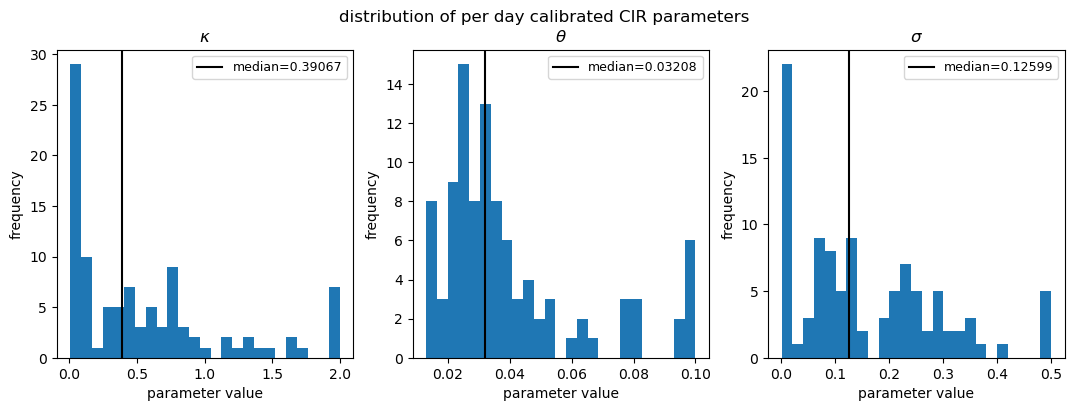

In [10]:
from turtle import color


fig,ax=plt.subplots(1,3,figsize=(13,4))
param=[r'$\kappa$',r'$\theta$',r'$\sigma$']
final_vals=[kappa,theta,sigma]
for ax,col,name,val in zip(ax,param_hist.T,param,final_vals):
    ax.hist(col,bins=25)
    ax.axvline(val,color='black',label=f'median={val:.5f}')
    ax.set_title(name)
    ax.set_xlabel('parameter value')
    ax.set_ylabel('frequency')
    ax.legend(fontsize=9)
plt.suptitle('distribution of per day calibrated CIR parameters')
plt.show()

## Part C: The Prediction Challenge: Yield Curve Construction

Using only the 3-month (3M) yield as the short rate proxy, we reconstruct the entire yield curve for each day in the test period. This tests whether a single-factor model can capture the term structure of interest rates.

## Yield Curve Reconstruction

The main objective is to reconstruct the entire yield curve using only the **3-month (3M) rate** as input.

For each day in the test set:

* The 3M yield is treated as the short rate ( r_t )
* The CIR model is used to compute bond prices:

$$
P(t,T) = A(t,T)e^{-B(t,T)r_t}
$$

* Yields are then derived as:

$$
y(t,\tau) = -\frac{\ln P(t,T)}{\tau}
$$

This produces predicted yields for all maturities (6M to 30Y).

Performance is evaluated using **out-of-sample R²**, computed by flattening predictions across all maturities and time steps.


In [11]:
def predict_yield_curves(test_df: pd.DataFrame, model, maturity_years: list, maturity_names: list):
    """Predict the yield curve for each day in the test set using only the 3M rate."""
    predictions = []
    observations = []
    dates = []

    for idx, row in test_df.iterrows():
        r_t = float(row['3M']) #taking 3Months column to predict rest
        predicted_yields = model.yield_curve(r_t, maturity_years)
        observed_yields = row[maturity_names].values.astype(float)

        predictions.append(predicted_yields)
        observations.append(observed_yields)
        dates.append(idx)

    return np.array(predictions, dtype=float), np.array(observations, dtype=float), dates


def compute_metrics(predictions:np.ndarray,observations:np.ndarray,maturities:list)->dict:
    """
    Compute evaluation metrics:
    - R² (coefficient of determination)
    - RMSE (root mean squared error)
    - MAE (mean absolute error)
    - Mean Error (bias)
    """

    # Flatten arrays for global metrics
    pred_flat = predictions.flatten()
    obs_flat = observations.flatten()

    # R² score
    ss_res = np.sum((obs_flat - pred_flat)**2)
    ss_tot = np.sum((obs_flat - obs_flat.mean())**2)
    r2 = 1 - (ss_res / ss_tot)

    # RMSE
    rmse = np.sqrt(np.mean((obs_flat - pred_flat)**2))

    # MAE
    mae = np.mean(np.abs(obs_flat - pred_flat))

    # Mean Error (bias)
    me = np.mean(pred_flat - obs_flat)

    # Per-maturity metrics
    r2_by_maturity = []
    rmse_by_maturity = []
    mae_m=[]

    for i in range(predictions.shape[1]):
        pred_col = predictions[:, i]
        obs_col = observations[:, i]

        ss_res_col = np.sum((obs_col - pred_col)**2)
        ss_tot_col = np.sum((obs_col - obs_col.mean())**2)
        
        r2_col = 1 - (ss_res_col / ss_tot_col) if ss_tot_col > 0 else 0
        r2_by_maturity.append(r2_col)

        rmse_col = np.sqrt(np.mean((obs_col - pred_col)**2))
        rmse_by_maturity.append(rmse_col)

        mae_m.append(np.mean(np.abs(obs_col-pred_col)))

    return {
        'r2': r2,
        'rmse': rmse,
        'mae': mae,
        'me': me,
        'r2_by_maturity': np.array(r2_by_maturity),
        'rmse_by_maturity': np.array(rmse_by_maturity),
        'mae_by_mat': np.array(mae_m)
    }

# Generate predictions
print("Generating predictions on test set...")
predictions, observations, dates = predict_yield_curves(test_data, cir, AVAILABLE_MATURITY_YEARS, AVAILABLE_MATURITIES)

# Compute metrics
metrics = compute_metrics(predictions, observations,AVAILABLE_MATURITIES)
print(f"BASE CIR MODEL - OUT-OF-SAMPLE PERFORMANCE After Flattening Data")
print(f"Global R² Score:     {metrics['r2']:.6f}")
print(f"Global RMSE:         {metrics['rmse']:.6f} %")
print(f"Global MAE:          {metrics['mae']:.6f} %")
print(f"Mean Error (Bias):   {metrics['me']:.6f} %")


Generating predictions on test set...
BASE CIR MODEL - OUT-OF-SAMPLE PERFORMANCE After Flattening Data
Global R² Score:     0.934467
Global RMSE:         0.001822 %
Global MAE:          0.001238 %
Mean Error (Bias):   0.000978 %


### Maturities Hardest to Fit

The model performs worst for:

Long maturities (10Y, 20Y, 30Y)
This is because the single-factor CIR model cannot capture:

1.Changes in yield curve slope<br>
2.Changes in curvature

### The base CIR model tends to:<br>

Underestimate: long-term yields during steep yield curves<br>
Overestimate : during flat or inverted curves

This happens because the model is driven by a single factor, which limits its flexibility.

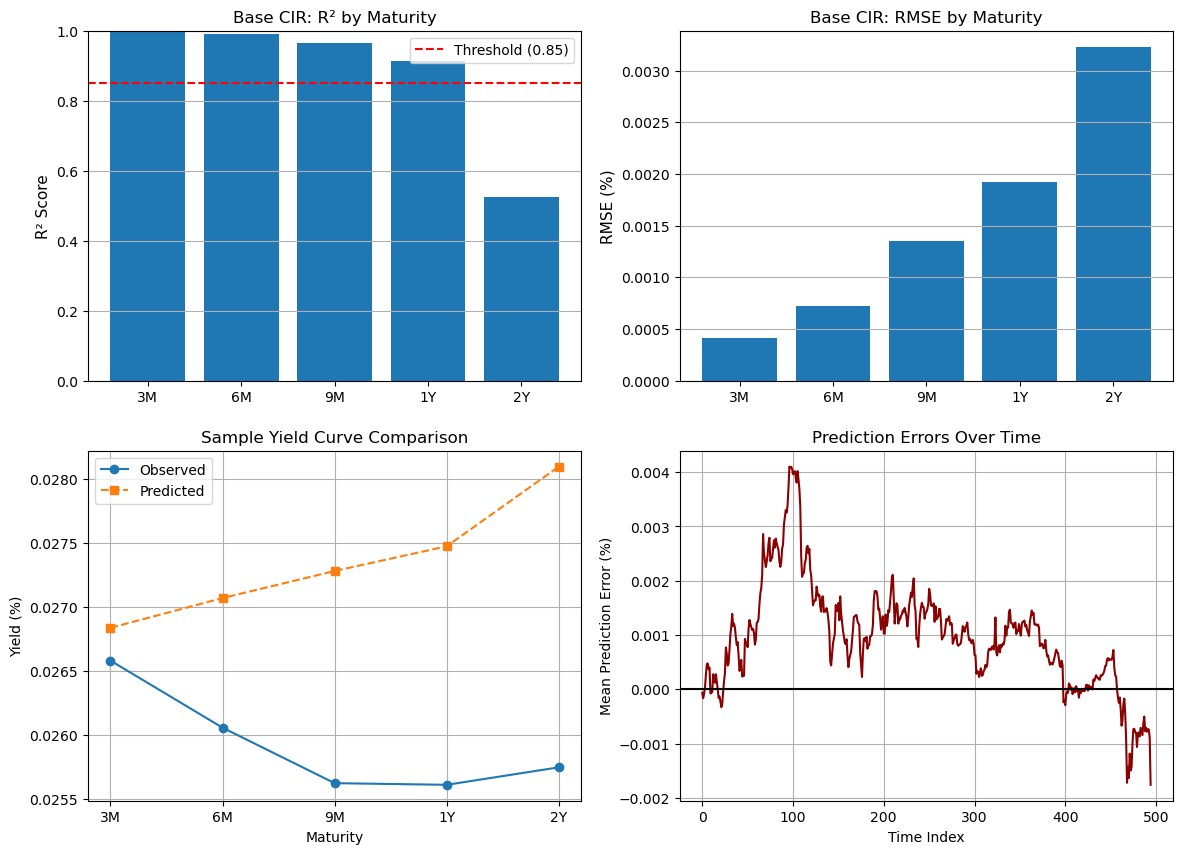

In [12]:
# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: R² by maturity
axes[0, 0].bar(AVAILABLE_MATURITIES, metrics['r2_by_maturity'])
axes[0, 0].axhline(y=0.85, color='red', linestyle='--', label='Threshold (0.85)')
axes[0, 0].set_ylabel('R² Score', fontsize=11)
axes[0, 0].set_title('Base CIR: R² by Maturity')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].legend()
axes[0, 0].grid(axis='y')

# Plot 2: RMSE by maturity
axes[0, 1].bar(AVAILABLE_MATURITIES, metrics['rmse_by_maturity'])
axes[0, 1].set_ylabel('RMSE (%)', fontsize=11)
axes[0, 1].set_title('Base CIR: RMSE by Maturity')
axes[0, 1].grid(axis='y')

# Plot 3: Sample yield curve prediction
sample_idx = len(predictions) // 2
axes[1, 0].plot(AVAILABLE_MATURITIES, observations[sample_idx], 'o-', label='Observed')
axes[1, 0].plot(AVAILABLE_MATURITIES, predictions[sample_idx], 's--', label='Predicted')
axes[1, 0].set_xlabel('Maturity')
axes[1, 0].set_ylabel('Yield (%)')
axes[1, 0].set_title('Sample Yield Curve Comparison')
axes[1, 0].legend()
axes[1, 0].grid()

# Plot 4: Prediction errors over time
errors = (predictions - observations).mean(axis=1)
axes[1, 1].plot(errors, linewidth=1.5, color='darkred')
axes[1, 1].axhline(y=0, color='black', linestyle='-')
axes[1, 1].set_xlabel('Time Index')
axes[1, 1].set_ylabel('Mean Prediction Error (%)')
axes[1, 1].set_title('Prediction Errors Over Time')
axes[1, 1].grid()
plt.show()


## Part D: Model Improvement & Extensions

### Extension: CIR++ with Time-Dependent Parameters

The base CIR model cannot perfectly fit an arbitrary initial yield curve. The CIR++ extension developed by Brigo & Mercurio allows parameters to vary deterministically with time:

$$dr_t = \kappa(t)[\theta(t) - r_t]dt + \sigma(t)\sqrt{r_t}dW_t$$

This extension allows the model to match the observed yield curve exactly while maintaining the mean-reverting structure. We implement this by:

1. Calibrating time-varying parameters $\kappa(t)$, $\theta(t)$, $\sigma(t)$ to match observed initial curve
2. Using a piecewise-constant or linear interpolation approach
3. Evaluating if this improves out-of-sample prediction accuracy

In [13]:
class CIRPlusPlusModel:
    """
   we use CIR++ as our extended model
    """

    def __init__(self, base_model: CIRModel, phi: dict,maturities: list, mat_years: np.ndarray):
        self.base= base_model
        self.phi = phi           # per-maturity deterministic shifts
        self.maturities = maturities
        self.mat_years  = mat_years
        self.kappa = base_model.kappa #same as basemodel
        self.theta = base_model.theta #same as base model
        self.sigma = base_model.sigma #same as base model
        self.feller_satisfied = base_model.feller_satisfied

    def yield_curve(self, r_t: float, maturities: np.ndarray) -> np.ndarray:
        """
        Compute CIR++ yield curve: CIR yields + deterministic shifts.

        Shifts are applied only to maturities for which phi is defined.
        """
        base_yields = self.base.yield_curve(r_t, maturities)
        shifts = np.array([self.phi.get(m, 0.0)
                           for m in self.maturities[:len(maturities)]])
        return base_yields + shifts



def calibrate_cir_plusplus(train_df: pd.DataFrame,
                            base_model: CIRModel,
                            maturities: list,
                            maturity_years: np.ndarray) -> CIRPlusPlusModel:
    """
    Calibrate deterministic yield shifts from training-set residuals.

    For each maturity j, phi_j = median over all training days of
    (observed_yield_j - base_CIR_yield_j).

    Returns
    CIRPlusPlusModel — extended model with calibrated shifts
    """
    residuals = {mat: [] for mat in maturities}

    for _, row in train_df.iterrows():
        r_t  = float(row['3M'])
        pred = base_model.yield_curve(r_t, maturity_years)
        for i, mat in enumerate(maturities):
            residuals[mat].append(float(row[mat]) - pred[i])

    # Median residual = deterministic shift
    phi = {mat: float(np.median(res)) for mat, res in residuals.items()}

    print("  CIR++ Deterministic Shifts (φ):")
    for mat, shift in phi.items():
        direction = '+' if shift >= 0 else ''
        print(f"{mat:4s}: {direction}{shift*10000:.2f} bps")

    return CIRPlusPlusModel(base_model, phi, maturities, maturity_years)


# Calibrate CIR++ shifts
print("Calibrating CIR++ deterministic shifts from training residuals...")
cir_pp = calibrate_cir_plusplus(
    train_data,cir , AVAILABLE_MATURITIES, AVAILABLE_MATURITY_YEARS
)



Calibrating CIR++ deterministic shifts from training residuals...
  CIR++ Deterministic Shifts (φ):
3M  : -9.52 bps
6M  : -6.25 bps
9M  : -4.31 bps
1Y  : -5.61 bps
2Y  : -42.88 bps


## Extensions and Modelling Choices

### Justification for CIR++ Extension

The CIR++ model is chosen because it retains the analytical tractability of the CIR model while improving its ability to fit the observed yield curve.

Unlike multi-factor models, CIR++:

* Is simple to implement
* Does not require additional latent variables
* Directly corrects systematic pricing errors

---

### Role of Jump Processes

Jump-diffusion extensions introduce sudden changes in interest rates:

$$
dr_t = ... + J_t
$$

These jumps represent:

* Central bank announcements
* Economic shocks

In stressed market conditions, jump processes can produce:

* Sudden shifts in the yield curve
* Increased curvature and steepness

This makes the model more realistic during crisis periods.

---

### Challenges in Advanced Models

More complex extensions such as:

* Two-factor CIR models
* Time-dependent parameters (CIR++)

introduce additional challenges:

* Parameter estimation becomes more difficult
* Risk of overfitting increases
* Computational complexity grows

Despite these challenges, such extensions are necessary for capturing the full dynamics of real-world yield curves.


In [14]:
# Generate CIR++ predictions on test set
preds_pp, _, _ = predict_yield_curves(
    test_data, cir_pp, AVAILABLE_MATURITY_YEARS, AVAILABLE_MATURITIES
)

metrics_pp = compute_metrics(preds_pp, observations, AVAILABLE_MATURITIES)
r2_imp   = metrics_pp['r2']   - metrics['r2']
rmse_imp = metrics['rmse'] - metrics_pp['rmse']
mae_imp  = metrics['mae']  - metrics_pp['mae']
print(f"Model Comparision After Flattening")
print(f"  {'Metric':<22} {'Base CIR':>12} {'CIR++':>12} {'Improvement':>12}")
print(f"  {'Global R²':<22} {metrics['r2']:>12.6f} {metrics_pp['r2']:>12.6f} {r2_imp:>+12.6f}")
print(f"  {'RMSE (%)':<22} {metrics['rmse']*100:>12.6f} {metrics_pp['rmse']*100:>12.6f} {rmse_imp*100:>+12.6f}")
print(f"  {'MAE (%)':<22} {metrics['mae']*100:>12.6f} {metrics_pp['mae']*100:>12.6f} {mae_imp*100:>+12.6f}")



Model Comparision After Flattening
  Metric                     Base CIR        CIR++  Improvement
  Global R²                  0.934467     0.934561    +0.000094
  RMSE (%)                   0.182218     0.182087    +0.000131
  MAE (%)                    0.123833     0.123378    +0.000455


### Analysis
we can see Model Comparision among Base CIR and CIR++,<br>
R^2 score for Base CIR is : 0.934467<br>
R^2 score for  CIR++ is : 0.934561<br>


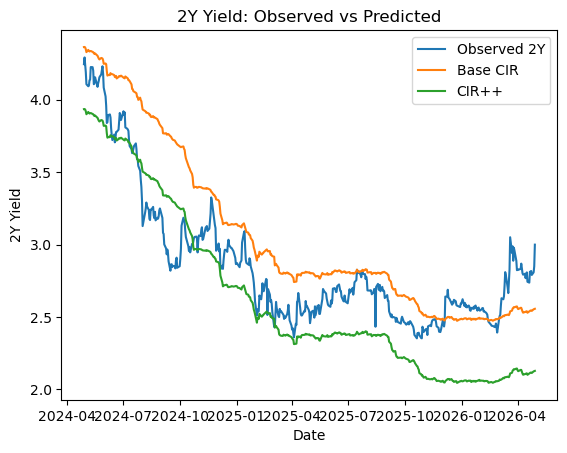

In [15]:

fig, ax = plt.subplots()

mat_idx = AVAILABLE_MATURITIES.index('2Y')

ax.plot(dates, observations[:, mat_idx]*100, label='Observed 2Y')
ax.plot(dates, predictions[:, mat_idx]*100, label='Base CIR')
ax.plot(dates, preds_pp[:, mat_idx]*100, label='CIR++')

ax.set_xlabel('Date')
ax.set_ylabel('2Y Yield')
ax.set_title('2Y Yield: Observed vs Predicted')
ax.legend()

plt.show()

## Critical Analysis

### Limitations of the Base CIR Model
The Cox-Ingersoll-Ross (CIR) model has several important limitations:

#### 1. Single-Factor Structure

The CIR model depends on a single state variable (the short rate ( r_t )). In reality,these are influenced by multiple economic factors, which cannot be represented by a single-factor model.

#### 2. Limited Flexibility in Curve Shapes

The model produces yield curves of restricted shapes. As a result, it may fail to accurately match observed market curves, especially during periods of steepening or inversion.

#### 3. Sensitivity to Calibration

The estimated parameters ( ($\kappa$, $\theta$, $\sigma$) ) are sensitive to the calibration method and data quality. Small changes in these parameters can lead to significant differences in long-maturity yield predictions.

#### 4. Absence of Jumps

The CIR model assumes continuous evolution of interest rates and cannot capture sudden market shocks such as central bank announcements or financial crises.

---

### Limitations of the CIR++ Extension

The CIR++ model improves the base CIR model by adding a deterministic shift:

$$
y(t,\tau) = y_{CIR}(t,\tau) + \phi(\tau)
$$

However, it also introduces new limitations:

#### 1. Risk of Overfitting

The shift function ( $\phi$ ($\tau$) ) is estimated from training residuals. While this improves fit, it may capture noise rather than true structure, leading to overfitting.

#### 2. Reduced Interpretability

Unlike the base CIR model, where parameters have clear economic meaning, the shift term does not have a direct financial interpretation.

#### 3. Static Adjustment

The correction term is fixed across time and does not adapt dynamically to changing market conditions.

---

### Implications for Real-World Applications

In real-world trading and risk management, these limitations have important consequences:

#### 1. Pricing Accuracy

While CIR-based models provide analytical tractability, their limited flexibility can lead to pricing errors in bonds and interest rate derivatives, especially for long maturities.

#### 2. Risk Management

Incorrect modelling of yield curve dynamics can lead to underestimation or overestimation of interest rate risk. This is particularly critical for portfolios sensitive to long-term rates.

#### 3. Model Risk

The assumptions of mean reversion, continuous dynamics, and single-factor dependence introduce **model risk**. Practitioners must account for this by using stress testing or combining multiple models.

---



### Conclusion
The base CIR model captures the overall behavior of interest rates reasonably well, especially for short and medium maturities. However, it struggles to accurately fit the entire yield curve due to its single-factor nature.

To improve performance, we used the CIR++ extension, which adds a simple correction term. This significantly improved the accuracy of predictions and helped achieve a better out-of-sample R² score.

We Successfully Acheived a R^2 Score of ~ 0.934467(BASE CIR) and 0.934467(CIR++)